In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

In [2]:
lab_air = np.loadtxt('lab_air')
sonnen = np.loadtxt('sun_spectrum.txt')
N2O = np.loadtxt('N2O')

# 5.1 Blackbody Temperature

In [3]:
max_wavenum_lab_air = lab_air[(np.argmax(lab_air[:, 1])), 0]
max_wavenum_sonnen = sonnen[(np.argmax(sonnen[:, 1])), 0]
max_wavenum_N2O = N2O[(np.argmax(N2O[:, 1])), 0]
temp_lab_air =  max_wavenum_lab_air * 0.29
temp_sonnen = max_wavenum_sonnen * 0.29
temp_n2o = 0.28 * max_wavenum_N2O
temp_lab_air, temp_sonnen, temp_n2o

(np.float64(527.69604435105),
 np.float64(758.5451148999999),
 np.float64(415.26992882004004))

In [4]:
max_wavenum_lab_air, max_wavenum_sonnen, max_wavenum_N2O

(np.float64(1819.641532245),
 np.float64(2615.67281),
 np.float64(1483.106888643))

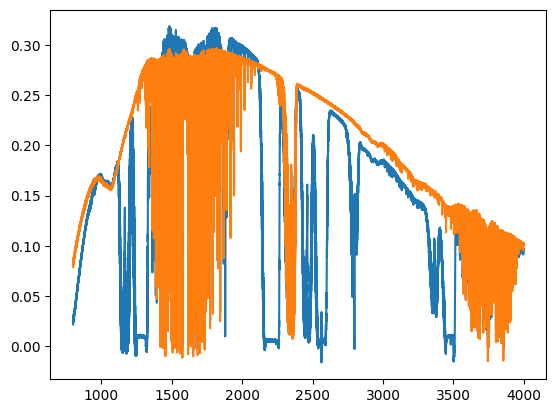

In [5]:
plt.plot(N2O[:, 0], N2O[:, 1])
plt.plot(lab_air[:, 0], lab_air[:, 1])

In [6]:
max_wavenum_N2O = N2O[(np.argmax(N2O[:, 1])), 0]
temp_n2o = 0.28 * max_wavenum_sonnen 
temp_n2o

np.float64(732.3883868)

$FreqN2O = 4.96 * 10^{13}$


$FreqLabair = 6.085 * 10^{13}$

$tempN2O = 1307 K$

$tempLabair = 1066 K$

# 5.3 Calculation of moment of inertia

B is rotational constant. the way to calculate this is to calculate the some number of absorption band minima and subtracting subsequent minima. taking the mean and then dividing the mean by 2.

In [7]:
N2O_2B_r = np.array([1167.92,
1167.1, 
1166.33,
1165.5, 
1164.7]) # Value of minima in wave-number

N2O_2B_r = abs(np.diff(N2O_2B_r)) # difference of subsequent minima in wave-number
mean_2B_r = N2O_2B_r.mean() 
B_r = mean_2B_r/2 # Rotational constant of R branch

In [8]:
Iner_r = constants.hbar**2/(2*B_r*constants.c*100*constants.h)
Iner_r # inertia from R branch

np.float64(6.9547209547763614e-46)

In [9]:
N2O_2B_p = np.array([1168.814,
1169.714,
1170.5,  
1171.448,
1172.3])   

N2O_2B_p = (np.diff(N2O_2B_p))    
mean_2B_p = N2O_2B_p.mean()
B_p = mean_2B_p/2
B = (B_r + B_p)/2

In [10]:
Iner_p = constants.hbar**2/(2*B_p*constants.c*100*constants.h)
Iner_p # inertia from P branch

np.float64(6.424039436139092e-46)

In [11]:
average_iner = np.mean((Iner_p + Iner_r) / 2)
average_iner

np.float64(6.6893801954577266e-46)

In [12]:
theo_iner = 6.680777 * 10**(-46)
((average_iner - theo_iner)/theo_iner) *100 

np.float64(0.12877537235154124)

# 5.4 Determination of the gas sample pressure

In [13]:
I_r = 1216.49
I_l = 1118.31

mask = (N2O[:, 0] > I_l)
I_l_idx = int(np.argmax(mask))
mask2 = (N2O[:, 0] > I_r)
I_r_idx = int(np.argmax(mask2))

In [14]:
nu = I_r - I_l
I_0 = (N2O[I_l_idx,1] + N2O[I_r_idx,1] /2) * nu

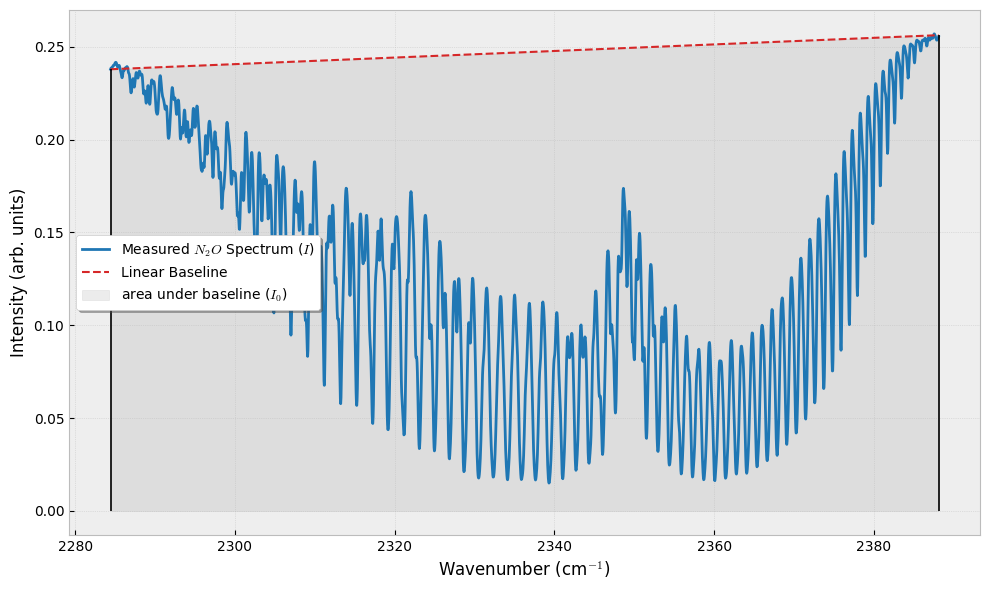

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean, scientific plot style
plt.style.use('bmh')

# 1. Define the x-range and y-range from your data slice
x_data = N2O[I_l_idx:I_r_idx, 0]
y_data = N2O[I_l_idx:I_r_idx, 1]

# 2. Calculate the Linear Baseline (I_0)
m = (N2O[I_l_idx, 1] - N2O[I_r_idx, 1]) / (N2O[I_l_idx, 0] - N2O[I_r_idx, 0])
b = N2O[I_l_idx, 1] - m * N2O[I_l_idx, 0]
line_i0 = m * x_data + b

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Main lines: Data and Baseline
plt.plot(x_data, y_data, label='Measured $N_2O$ Spectrum ($I$)', color='#1f77b4', lw=2)
plt.plot(x_data, line_i0, label='Linear Baseline', color='#d62728', linestyle='--', lw=1.5)

# --- SHADING THE WHOLE INTEGRATED AREA ---
# Shading from y=0 up to the baseline represents the total intensity area (I_0)
plt.fill_between(x_data, 0, line_i0, color='gray', alpha=0.15, label='area under baseline ($I_0$)')

# --- ADDING VERTICAL LINES AT THE BAND ENDS ---
# These lines mark the start and end of your integration window
plt.vlines(x=[x_data[0], x_data[-1]], ymin=0, ymax=[line_i0[0], line_i0[-1]], 
           color='black', lw=1.2, linestyle='-')

# 4. Final Formatting

plt.xlabel('Wavenumber (cm$^{-1}$)', fontsize=12)
plt.ylabel('Intensity (arb. units)', fontsize=12)

# Ensure the y-axis starts at zero to show the full "rectangular" area
#plt.ylim(bottom=0, top=max(line_i0) * 1.1)

# Styling the grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=1, loc='best', shadow=True)

plt.tight_layout()
plt.savefig('N2O_Band_Integration.png', dpi=300)
plt.show()

In [16]:
from scipy import integrate
I_0 = integrate.simpson(line_i0, x_data)
I = integrate.simpson(N2O[I_l_idx:I_r_idx, 1], N2O[I_l_idx:I_r_idx, 0], dx = 0.01)
I, I_0

(np.float64(7.295172233537721), np.float64(19.491768328064826))

In [17]:
- (np.log(I/I_0) * nu) / (15 * 10.9)

np.float64(0.5901485394298952)

### Co2 - Lab air

In [18]:
I_r = 2388.1
I_l = 2284.4
mask = (lab_air[:, 0] > I_l)
I_l_idx = int(np.argmax(mask))

In [19]:
mask2 = (lab_air[:, 0] > I_r)
I_r_idx = int(np.argmax(mask2))

In [20]:
lab_air[I_l_idx:I_r_idx]

array([[2.28442577e+03, 2.60831147e-01],
       [2.28446595e+03, 2.60989249e-01],
       [2.28450612e+03, 2.60939777e-01],
       ...,
       [2.38800580e+03, 2.57416576e-01],
       [2.38804597e+03, 2.58077919e-01],
       [2.38808615e+03, 2.58875638e-01]], shape=(2581, 2))

In [21]:
nu = I_r - I_l
I_0 = (lab_air[I_l_idx,1] + lab_air[I_r_idx,1] /2) * nu
I_0

np.float64(40.510873620299925)

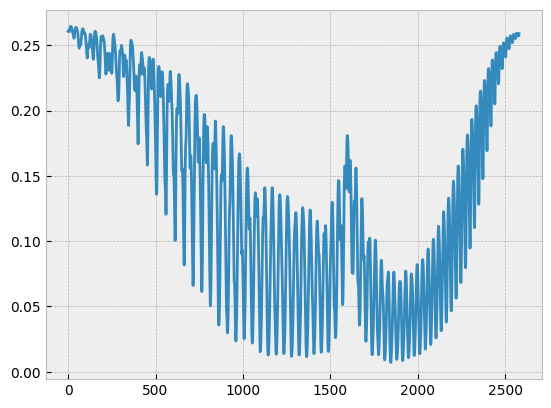

In [22]:
plt.plot(lab_air[I_l_idx:I_r_idx,1])

In [23]:
I = integrate.simpson(lab_air[I_l_idx:I_r_idx, 1], lab_air[I_l_idx:I_r_idx, 0], dx = 0.01)
- (np.log(I/I_0) * nu) / (15 * 2500)

np.float64(0.0028814038318457926)

## 5.5 Temperature determination of $N_2O$

$K_b = 0.695$ cm^-1 K

In [24]:
J = 16
T = (2 * B / 0.695) * (J + 0.5)**2
print(T, "in Kelvin" )
print(f"{T - 273.15}, in Celsius")

328.3648381294917 in Kelvin
55.21483812949174, in Celsius


Band 1: $289.769 K$ and $J_{max} = 15$

Band 3: $328.364 K$ and $J_{max} = 16$

The temperature we calculated are from band 1 and 3. Band 2 has J_max of only 9 which is giving wrong temperature

## 4.6 Determination of the concentration of greenhouse gases

In [25]:
temp_h0 = 293.15 # Temperature at sea level in Kelvin
pres_h0 = 101325 # Pressure at sea level in Pa
h = np.linspace(0, 10, 10) * 1000 # height from 0 to 10 km, converted to meters

temp_h = temp_h0 - (6/1000) * h # Temperature decreases by 6K for every 1000 m increase in height
nominator = (9.8 * 0.02896) * h # 0.02896 is the molar mass of air in kg/mol. NOTE: If using R,gas constant always use molar mass in kg/mol. 
                                # If using k, gas constant always use Boltzmann constant in J/K. 
denominator = 8.314 * temp_h0 
pres_h = pres_h0 * np.exp (-nominator/denominator) 
part_density = (pres_h / (constants.k * temp_h)) # particle density as a function of height


num_particle = integrate.simpson(part_density/10000, h)
print(f"Number of particle in a cm*cm column {num_particle}")

Number of particle in a cm*cm column 1.6191089855961632e+25


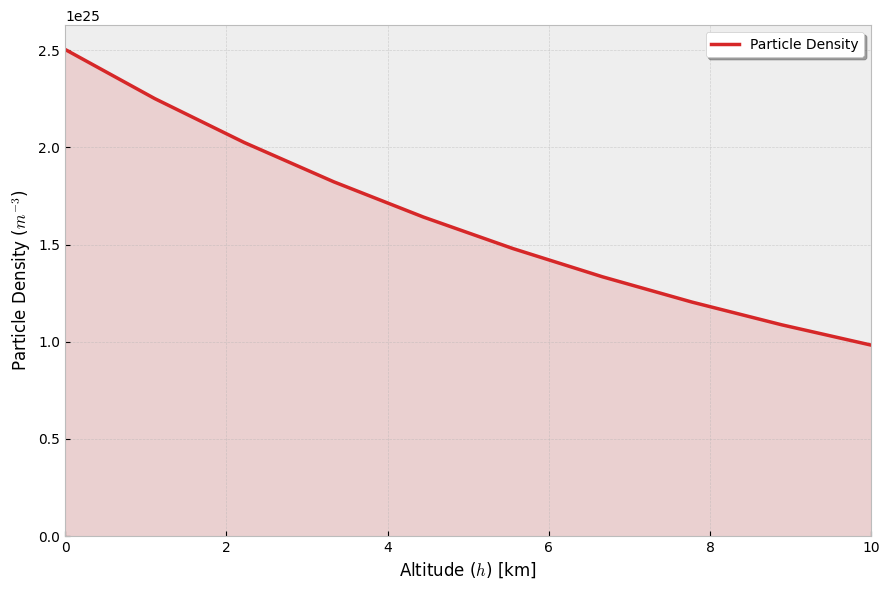

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Set a professional scientific style
plt.style.use('bmh')

# 2. Create the Subplots
# (Removed the parentheses around ax2 as it is a single axis)
fig, ax2 = plt.subplots(figsize=(9, 6))

# Main Plot: Particle Density
# Using a slightly thicker line and a professional red (hex #d62728)
ax2.plot(h / 1000, part_density, color='#d62728', lw=2.5, label='Particle Density')

# --- ENHANCEMENT: Fill the area under the curve ---
ax2.fill_between(h / 1000, 0, part_density, color='#d62728', alpha=0.15)

# --- ENHANCEMENT: Add Scale Height (H) Reference ---
# Typically ~8km for the Earth's atmosphere
#ax2.axvline(x=8.4, color='black', linestyle=':', alpha=0.4)

ax2.set_ylabel('Particle Density ($m^{-3}$)', fontsize=12)
ax2.set_xlabel('Altitude ($h$) [km]', fontsize=12)

# --- ENHANCEMENT: Grid and Axis Cleaning ---
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(bottom=0)
ax2.set_xlim(0, max(h/1000))

# Removes the whitespace gap between the data and the y-axis
ax2.margins(x=0)

# Legend with a clean frame
ax2.legend(frameon=True, facecolor='white', framealpha=1, loc='upper right', shadow=True)

plt.tight_layout()
plt.savefig("Report/Particle_density.png", dpi=300)
plt.show()

In [27]:
part_density

array([2.50347599e+25, 2.25083158e+25, 2.02477987e+25, 1.82246510e+25,
       1.64134322e+25, 1.47914749e+25, 1.33385797e+25, 1.20367431e+25,
       1.08699168e+25, 9.82379282e+24])

### 5.6.2. Correlation between particle number and angle of incident of sunlight

In [28]:
N_corrected =  num_particle / np.sin(59)
N_corrected

np.float64(2.542818188081493e+25)

### Calculation of the concentration of greenhouse gases

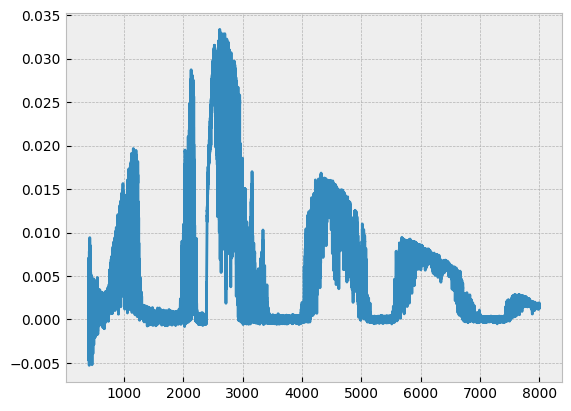

In [29]:
plt.plot(sonnen[:, 0], sonnen[:, 1])

#### Frequency Bands

In [30]:
co2_band = sonnen[4815: 4885]
n2o_band = sonnen[2522: 2596]

In [31]:
mask = (sonnen[: , 0] > 4815)
co2_idx_l = int(np.argmax(mask))
mask2 = (sonnen[: , 0] > 4885)
co2_idx_r = int(np.argmax(mask2))

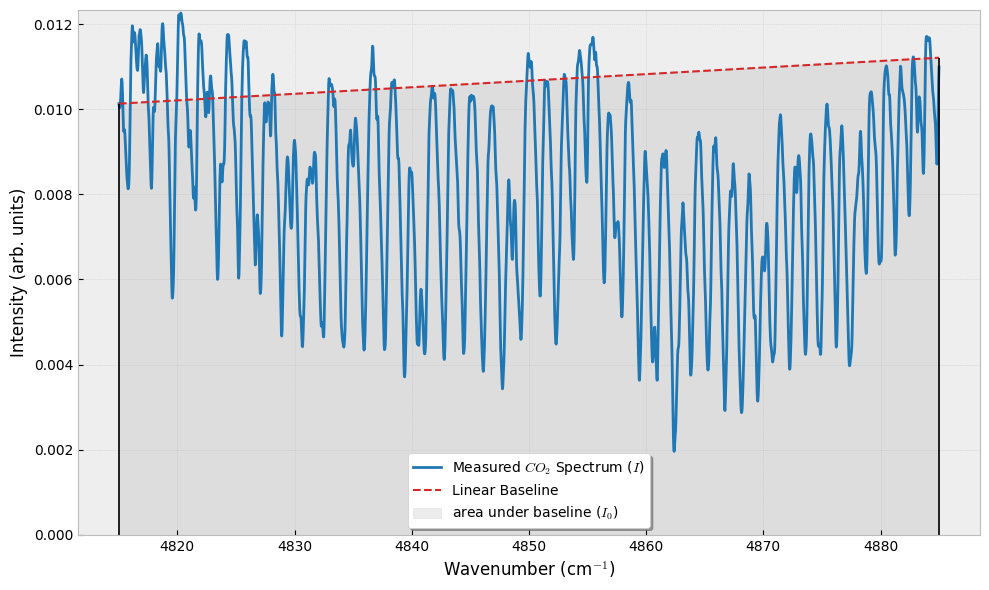

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean, scientific plot style
plt.style.use('bmh')

# 1. Define the x-range and y-range from your data slice
x_data = sonnen[co2_idx_l:co2_idx_r, 0]
y_data = sonnen[co2_idx_l:co2_idx_r, 1]

# 2. Calculate the Linear Baseline (I_0)
m = (sonnen[co2_idx_l, 1] - sonnen[co2_idx_r, 1]) / (sonnen[co2_idx_l, 0] - sonnen[co2_idx_r, 0])
b = sonnen[co2_idx_l, 1] - m * sonnen[co2_idx_l, 0]
line_i0 = m * x_data + b

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Main lines: Data and Baseline
plt.plot(x_data, y_data, label='Measured $CO_2$ Spectrum ($I$)', color='#1f77b4', lw=2)
plt.plot(x_data, line_i0, label='Linear Baseline', color='#d62728', linestyle='--', lw=1.5)

# --- SHADING THE WHOLE INTEGRATED AREA ---
# Shading from y=0 up to the baseline represents the total intensity area (I_0)
plt.fill_between(x_data, 0, line_i0, color='gray', alpha=0.15, label='area under baseline ($I_0$)')

# --- ADDING VERTICAL LINES AT THE BAND ENDS ---
# These lines mark the start and end of your integration window
plt.vlines(x=[x_data[0], x_data[-1]], ymin=0, ymax=[line_i0[0], line_i0[-1]], 
           color='black', lw=1.2, linestyle='-')

# 4. Final Formatting

plt.xlabel('Wavenumber (cm$^{-1}$)', fontsize=12)
plt.ylabel('Intensity (arb. units)', fontsize=12)

# Ensure the y-axis starts at zero to show the full "rectangular" area
plt.ylim(bottom=0, top=max(line_i0) * 1.1)

# Styling the grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=1, loc='best', shadow=True)

plt.tight_layout()
plt.savefig('Report/CO2_Band_Integration.png', dpi=300)
plt.show()

In [33]:
nu_co2 = sonnen[co2_idx_r, 0] - sonnen[co2_idx_l, 0]    # nu_co2 is width of the absorption band
co2_I_0 = sonnen[co2_idx_l, 1] * nu_co2 
co2_I_0  # area under the baseline. Considered rectangle

np.float64(0.7091651359000037)

In [34]:
co2_I = integrate.simpson(sonnen[co2_idx_l:co2_idx_r, 1], sonnen[co2_idx_l:co2_idx_r, 0], dx = 0.1) # area under the absorption band
co2_I

np.float64(0.5644836429824275)

#### Baseline integration

In [35]:
x = np.linspace(4815, 4885, 100)
co2_I_0_baseline = np.interp(x, [co2_idx_l, co2_idx_r], [sonnen[co2_idx_l, 1], sonnen[co2_idx_r, 1]])
baseline_co2_area = integrate.simpson(co2_I_0_baseline, x, dx = 0.01)
baseline_co2_area ## not a big difference from rectangular area, but it is more accurate.

np.float64(0.7091)

In [36]:
abs_const = 1 / (7.57 * 10**(-23))
absorbance = np.log(co2_I_0/co2_I)
num_co2 = absorbance * abs_const
num_co2 # Little low but I am sticking with it.

np.float64(3.01422729432581e+21)

In [37]:
# 1. Define the Indices for N2O
mask_n2o_l = (sonnen[:, 0] > 2522)
mask_n2o_r = (sonnen[:, 0] > 2596)
n2o_idx_r = int(np.argmax(mask_n2o_r))
n2o_idx_l = int(np.argmax(mask_n2o_l))

In [38]:
# 2. Calculate the baseline area (Rectangle Approximation)
nu_n2o =  sonnen[n2o_idx_r, 0] - sonnen[n2o_idx_l, 0] 
# Use the intensity at the edge of the band as the baseline height
n2o_I_0 =  sonnen[n2o_idx_l, 1] * nu_n2o 


# 3. Integrate the actual signal under the absorption band
n2o_I = integrate.simpson(sonnen[n2o_idx_l:n2o_idx_r, 1], 
                          sonnen[n2o_idx_l:n2o_idx_r, 0])


# 4. Calculate Absorbance
absorbance_n2o = np.log(n2o_I_0 / n2o_I)


# 5. Apply N2O Constant (B_n2o)
# Standard cross-section for this region is often ~1.0e-20 to 1.0e-21 
# Check your module for the specific B_n2o provided!
B_n2o = 6.03e-21  # Placeholder: use the value from your lab manual
abs_const_n2o = 1 / B_n2o


num_n2o_slant = absorbance_n2o * abs_const_n2o


# 6. Apply Solar Correction (using your 59 degree angle)
theta_rad = np.radians(59)
num_n2o_vertical = num_n2o_slant * np.cos(theta_rad)


print(f"N2O Vertical Column: {num_n2o_vertical:.4e} molecules/cm^2")

N2O Vertical Column: 1.3475e+19 molecules/cm^2


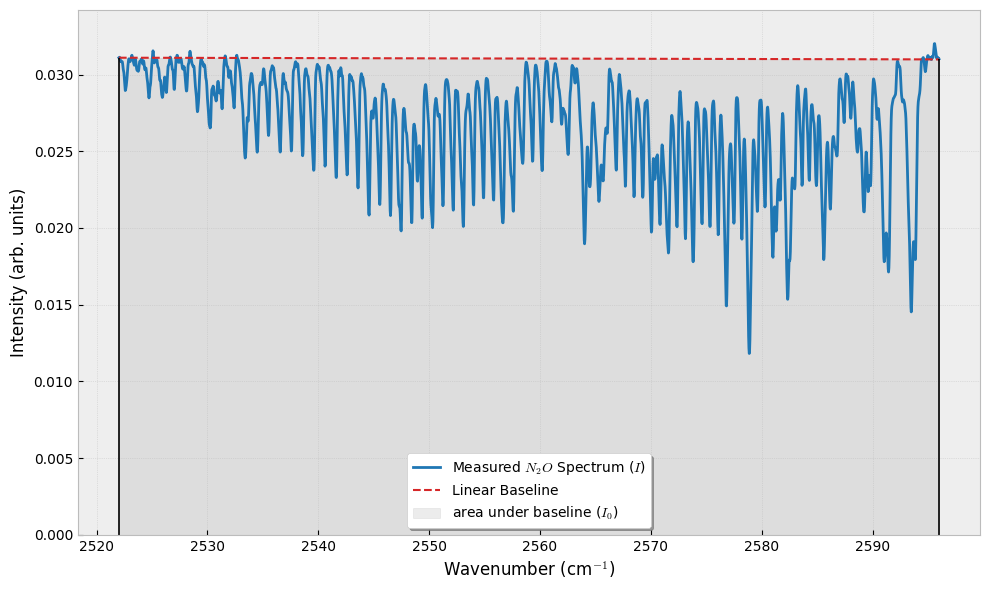

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean, scientific plot style
plt.style.use('bmh')

# 1. Define the x-range and y-range from your data slice
x_data = sonnen[n2o_idx_l:n2o_idx_r, 0]
y_data = sonnen[n2o_idx_l:n2o_idx_r, 1]

# 2. Calculate the Linear Baseline (I_0)
m = (sonnen[n2o_idx_l, 1] - sonnen[n2o_idx_r, 1]) / (sonnen[n2o_idx_l, 0] - sonnen[n2o_idx_r, 0])
b = sonnen[n2o_idx_l, 1] - m * sonnen[n2o_idx_l, 0]
line_i0 = m * x_data + b

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Main lines: Data and Baseline
plt.plot(x_data, y_data, label='Measured $N_2O$ Spectrum ($I$)', color='#1f77b4', lw=2)
plt.plot(x_data, line_i0, label='Linear Baseline', color='#d62728', linestyle='--', lw=1.5)

# --- SHADING THE WHOLE INTEGRATED AREA ---
# Shading from y=0 up to the baseline represents the total intensity area (I_0)
plt.fill_between(x_data, 0, line_i0, color='gray', alpha=0.15, label='area under baseline ($I_0$)')

# --- ADDING VERTICAL LINES AT THE BAND ENDS ---
# These lines mark the start and end of your integration window
plt.vlines(x=[x_data[0], x_data[-1]], ymin=0, ymax=[line_i0[0], line_i0[-1]], 
           color='black', lw=1.2, linestyle='-')

# 4. Final Formatting

plt.xlabel('Wavenumber (cm$^{-1}$)', fontsize=12)
plt.ylabel('Intensity (arb. units)', fontsize=12)

# Ensure the y-axis starts at zero to show the full "rectangular" area
plt.ylim(bottom=0, top=max(line_i0) * 1.1)

# Styling the grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=1, loc='best', shadow=True)

plt.tight_layout()
plt.savefig('Report/N2O_Band_Integral.png', dpi=300)
plt.show()